In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, QTable, vstack
from tqdm import tqdm
import astropy.units as u
from astropy.io import fits
from astropy.modeling import functional_models, models, fitting
from photutils.aperture import CircularAnnulus, CircularAperture
from photutils.aperture import ApertureStats
from astropy.convolution import Gaussian2DKernel, convolve
from astropy.wcs import WCS
import glob
import scipy
from lmfit import Model, Parameters
from scipy.optimize import curve_fit
from scipy import signal
import scipy.ndimage as ndimage
from astropy.stats import sigma_clip


import lib
from subscan_class import Subscan
from binner import Binner
from cleaner_class import Cleaner
from cleaner_masked_class import Cleaner_masked
import focus_lib

def lin_func(x, m, q):
    return m*x+q
    
def band_pass_filter(time_series, cuton_freq, cutoff_freq, sampling_rate, order=4):
    """
    Apply a band-pass Butterworth filter to a time series.

    Parameters:
    - time_series (array-like): The input time-series data.
    - cuton_freq (float): The lower cutoff frequency (cut-on frequency) in Hz.
    - cutoff_freq (float): The upper cutoff frequency (cut-off frequency) in Hz.
    - sampling_rate (float): The sampling rate of the data in Hz.
    - order (int): The order of the Butterworth filter (default is 4).

    Returns:
    - filtered_series (numpy array): The filtered time-series data.
    """
    nyquist = 0.5 * sampling_rate  # Nyquist frequency
    normal_cuton = cuton_freq / nyquist  # Normalized cut-on frequency
    normal_cutoff = cutoff_freq / nyquist  # Normalized cut-off frequency
    
    # Design Butterworth band-pass filter
    b, a = signal.butter(order, [normal_cuton, normal_cutoff], btype='band', analog=False)
    
    # Apply the band-pass filter
    filtered_series = signal.filtfilt(b, a, time_series)
    
    return filtered_series

def low_pass_filter(time_series, cutoff_freq, sampling_rate, order=4):
    """
    Apply a low-pass Butterworth filter to a time series.

    Parameters:
    - time_series (array-like): The input time-series data.
    - cutoff_freq (float): The cutoff frequency of the low-pass filter in Hz.
    - sampling_rate (float): The sampling rate of the data in Hz.
    - order (int): The order of the Butterworth filter (default is 4).

    Returns:
    - filtered_series (numpy array): The filtered time-series data.
    """
    nyquist = 0.5 * sampling_rate  # Nyquist frequency
    normal_cutoff = cutoff_freq / nyquist  # Normalized cutoff frequency
    
    # Design Butterworth low-pass filter
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    
    # Apply the filter
    filtered_series = signal.filtfilt(b, a, time_series)
    
    return filtered_series



In [2]:
cfg = lib.get_config_file("/Users/eleonora/Desktop/mistral/FOCUS_YOFFSET/config_focusY.yaml")

tods_dir = cfg['paths']['tods']
tods_names = os.listdir(tods_dir)
tods_files = []
for name in tods_names:
    tods_files.append(os.path.join(tods_dir, name))
tods_files.sort()
print('Making maps of: ', tods_dir)
print('Total number of subscan:', len(tods_names))

subscan = Subscan(cfg, mode=cfg['telescope'])

#Checking if number of feeds changes during the subscans
lib.check_number_channel(tods_files)

name_target = cfg['name_target']

bin_mode = cfg['binner']['frame']
projection = cfg['binner']['projection']
binner = Binner(bin_mode=bin_mode, projection=projection)
print('Binner mode = ', bin_mode)
print('Projection = ', projection)

Making maps of:  /Users/eleonora/Desktop/SRT-marzo/20250404-181903-MISTRAL-YOFFSET_MARS_TZ-2
Total number of subscan: 23
-------------------------------------
         Telescope: SRT  
-------------------------------------
Diameter = 60 m
Band = 90.0-120.0 GHz
Efficiency = 0.3 
Gaussian beam = ????????????? 
Beam area = ???????????? 
-------------------------------------
Binner mode =  AZEL
Projection =  SIN


In [3]:

print('Extracting data from files....')

cleaner = Cleaner(cfg)
scan = Table(names=('TY', 'n_subscan', 'ch', 't', 'lon', 'lat', 'tod_raw', 'tod_dt', 'ch_masks', 'tod_filt', cleaner.cm_type), 
             dtype=('S3', 'S3', 'i4', 'f8', 'f8', 'f8', 'f8', 'f8', '?', 'f8', 'f8'))
scan_sched = Table(names=('ra_discos', 'dec_discos', 'par_angle'))

file_resp = cfg['paths']['resp']
file_offset_feed = cfg['paths']['offset_pixel']
nsubscans = []
subscan_list = []
coords_list = []

subscan.extract_data(tods_files[0], cfg)
name_schedule = subscan.name_schedule

if '70deg' in name_schedule:
    range_pos = [1,0,-1,-2] #[4,2,0,-2,-4,-5,-6]
if '60deg' in name_schedule:
    range_pos = [0,-1,-2,-3]
if '50deg' in name_schedule:
    range_pos = [-4,-3,-2,-1] #[3,2,1,0,-1,-2,-3]
if '40deg' in name_schedule:
    range_pos = [-4,-3,-2,-1] #[0,-1,-2,-3,-4,-5,-6]
if '30deg' in name_schedule:
    range_pos = [-4,-3,-2,-1] #[3,2,1,0,-1,-2,-3]
else: 
    range_pos = [-4,-3,-2,-1]

print('NAME SCHEDULE:    ', name_schedule)
print('TY RANGE:   ', range_pos)
#range_pos = cfg['range_ty']
num_pos = len(range_pos)
num_subscan = round(len(tods_files)/num_pos)
array_pos = []
for i in range(len(range_pos)):
    array_pos.append( [range_pos[i]]*num_subscan)
array_pos = np.concatenate(array_pos)

for filename, nsub in tqdm(zip(tods_files, range(len(tods_files)))):
    n_subscan = filename.split('.fits')[0].split('_')[-1]
    nsubscans.append(n_subscan)
    ss_in = int(nsubscans[0])

    subscan.extract_data(filename, cfg)
    
    #skippo i file vuoti
    if any(len(lst) == 0 for lst in [subscan.par_angle, subscan.ra_scan, subscan.dec_scan, subscan.timestream_raw]) is True:
        print('Empty file skipped: ', filename)
        continue
    
    elif all(len(lst) != subscan.num_timestep for lst in [subscan.par_angle, subscan.ra_scan, 
                                                          subscan.dec_scan]):
        raise ValueError(f'The lengths of lists do not match. Length timstep = {subscan.num_timestep}. Length par_angle = {len(subscan.par_angle)}. Length RA = {len(subscan.ra_scan)}. Length dec = {len(subscan.dec_scan)}.')
    
    ts_resp = lib.responsivity(cfg, subscan.sample_freq, subscan.num_feed, subscan.timestream_raw)
    
    tsdt = []
    pixel_mask = []
    tsdt1 = []
    pixel_mask1 = []
    tsdt2 = []
    pixel_mask2 = []
    for i in range(subscan.num_feed): 
        dt_ts, maskfeed = lib.lindetrend(ts_resp[i], subscan.range_timestep, mode='sigma')
        tsdt.append(dt_ts)
        pixel_mask.append(maskfeed)
    
    '''
    for i in range(subscan.num_feed): 
        filtered_data = sigma_clip(tsdt1[i], sigma=5, maxiters=10) #result: masked array = masked array + mask (true = wanted values, false = masked values)
        mask = np.logical_not( np.ma.array(filtered_data).recordmask )
        filt = np.ma.masked_array(tsdt1[i], mask=mask)
        time = np.array(range(len(tsdt1[i])))
        timestep = np.ma.masked_array(time, mask=mask)
        #linear fit and subtraction of the best fit from the data (detrend)
        parfit, covfit = curve_fit(f=lin_func, xdata=timestep, ydata=filt)
        res = tsdt1[i] - lin_func(time, *parfit)
        tsdt.append(res)
        pixel_mask.append(mask)
    '''
    ts_filt, cm = cleaner.filter(subscan, tsdt, pixel_mask)
    
    binner.binner_clean()
    x, y = binner.proj_radec_to_xy(ra=subscan.ra_scan, dec=subscan.dec_scan, 
                               ra0=subscan.ra_center, dec0=subscan.dec_center, projection=projection)
    binner.conv_xy_to_latlon(x=x, y=y, par_angle=-subscan.par_angle, num_feed=subscan.num_feed,
                         offset_x = np.array(subscan.offset_x), offset_y=np.array(subscan.offset_y),
                         center_ra=subscan.ra_center, center_dec=subscan.dec_center)
    
    ss = [n_subscan]*subscan.num_timestep*subscan.num_feed
    t_list = list(subscan.time)*subscan.num_feed
    ch_list = [int(0)]*subscan.num_timestep
    for i in range(1, subscan.num_feed):
        ch_list += [int(i)]*subscan.num_timestep
    
    ty = [str(array_pos[nsub])]*subscan.num_timestep*subscan.num_feed #lib.choose_ty(n_subscan, ss_in, subscan.num_timestep, subscan.num_feed, range_ty, num_pos)
    subscan_table = Table([ty, ss, ch_list, t_list, list(np.hstack(binner.lon)), list(np.hstack(binner.lat)), np.hstack(subscan.timestream_raw), np.hstack(tsdt), 
                           np.hstack(pixel_mask), np.hstack(ts_filt), np.hstack(cm)],
                        names=['TY', 'n_subscan', 'ch', 't', 'lon', 'lat', 'tod_raw', 'tod_dt', 'ch_masks', 'tod_filt', cleaner.cm_type],
                        dtype=('S5', 'S3', 'i4', 'f8', 'f8', 'f8', 'f8', 'f8', '?', 'f8', 'f8'))
    #numero di righe di scan = num_timestep * num_canali
    subscan_list.append(subscan_table)
    
    
    coords = Table([subscan.ra_scan, subscan.dec_scan, subscan.az_scan, subscan.el_scan, subscan.par_angle], names=['ra_discos', 'dec_discos','az_discos', 'el_discos', 'par_angle'])
    coords_list.append(coords)
    #numero di righe di scan = (num_timestep * num_canali) * num_scan

scan = vstack(subscan_list)
scan_sched = vstack(coords_list) 

print('Data extracted!')
    

Extracting data from files....
Filtering the data with the customized common mode.
NAME SCHEDULE:     MATRIX_SCAN_MARS_OTFC_70deg_ridotta_2025094171655
TY RANGE:    [-4, -3, -2, -1]


23it [00:17,  1.32it/s]


Data extracted!


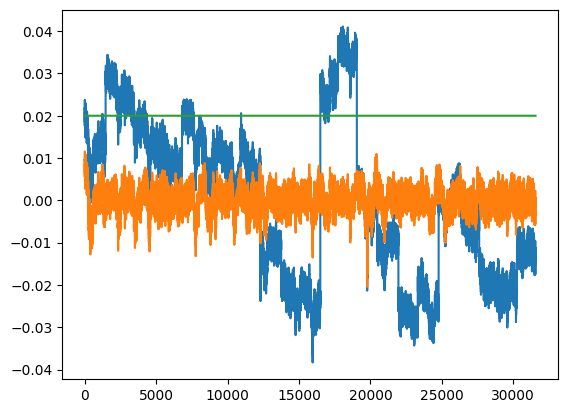

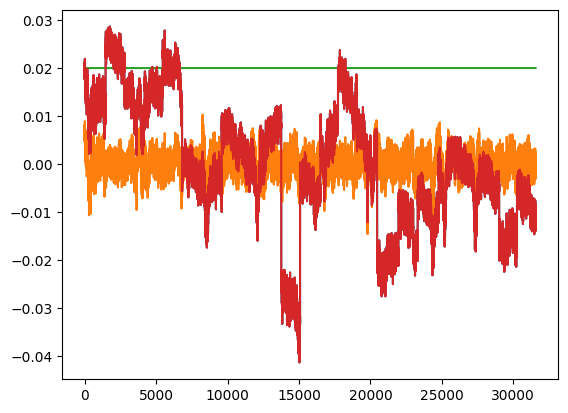

In [4]:
from scipy.optimize import curve_fit
def lin_func(x, m, q):
    return m*x+q

ch=5
ts = scan[scan['ch']==ch]['tod_raw']
mask = scan[scan['ch']==ch]['ch_masks']
time = range(len(ts[mask]))
parfit, covfit = curve_fit(f=lin_func, xdata=time, ydata=ts[mask])
res = ts - lin_func(range(len(ts)), *parfit)

plt.plot(scan[scan['ch']==ch]['tod_raw']-np.mean(scan[scan['ch']==ch]['tod_raw']))
plt.plot(scan[scan['ch']==ch]['tod_dt'])
plt.plot(scan[scan['ch']==ch]['ch_masks']*0.02)
#plt.plot(res)
#plt.plot(lin_func(range(len(ts)), *parfit)-np.mean(scan[scan['ch']==ch]['tod_raw']))
plt.show()

ch=0
ts = scan[scan['ch']==ch]['tod_raw']
mask = scan[scan['ch']==ch]['ch_masks']
time = range(len(ts[mask]))
parfit, covfit = curve_fit(f=lin_func, xdata=time, ydata=ts[mask])
res = ts - lin_func(range(len(ts)), *parfit)

plt.plot(scan[scan['ch']==ch]['tod_raw']-np.mean(scan[scan['ch']==ch]['tod_raw']))
plt.plot(scan[scan['ch']==ch]['tod_dt'])
plt.plot(scan[scan['ch']==ch]['ch_masks']*0.02)
plt.plot(ts[mask]-np.mean(scan[scan['ch']==ch]['tod_raw']))
#plt.plot(res)
#plt.plot(lin_func(range(len(ts)), *parfit)-np.mean(scan[scan['ch']==ch]['tod_raw']))
plt.show()

In [5]:
if cfg['num_ch_map']=='all':
    n_ch = np.copy(subscan.num_feed)
elif cfg['num_ch_map']<subscan.num_feed:
    n_ch = cfg['num_ch_map']
else:
    raise ValueError('Choose an adequate number of channel with which build the map.')

pixel_size=cfg['pixel_size']
n_pixel = 256

mappe_filt = []
mappe_unfilt = []
counts = []
for y in range_pos:
    print('TY '+str(y))
    focus_scan = scan[scan['TY']==str(y)]
    for i in tqdm(range(n_ch)):  
        data_filt_map, count_map, scan_wcs = binner.bin_map(lon=focus_scan['lon'][focus_scan['ch']==i], lat=focus_scan['lat'][focus_scan['ch']==i], 
                                            tods=focus_scan['tod_filt'][focus_scan['ch']==i],
                                            center_ra=subscan.ra_center, center_dec=subscan.dec_center,
                                            npix_x=n_pixel, npix_y=n_pixel, pixel_size_deg=pixel_size/3600)
        if cfg['unfilt_map']=='raw':
            data_unfilt_map, count_map1, scan_wcs = binner.bin_map(lon=focus_scan['lon'][focus_scan['ch']==i], lat=focus_scan['lat'][focus_scan['ch']==i], 
                                            tods=focus_scan['tod_raw'][focus_scan['ch']==i],
                                            center_ra=subscan.ra_center, center_dec=subscan.dec_center,
                                            npix_x=n_pixel, npix_y=n_pixel, pixel_size_deg=pixel_size/3600)
            
        if cfg['unfilt_map']=='dt':
            data_unfilt_map, count_map1, scan_wcs = binner.bin_map(lon=focus_scan['lon'][focus_scan['ch']==i], lat=focus_scan['lat'][focus_scan['ch']==i], 
                                            tods=focus_scan['tod_dt'][focus_scan['ch']==i],
                                            center_ra=subscan.ra_center, center_dec=subscan.dec_center,
                                            npix_x=n_pixel, npix_y=n_pixel, pixel_size_deg=pixel_size/3600)

        mappe_filt.append(data_filt_map)
        mappe_unfilt.append(data_unfilt_map)
        counts.append(count_map)
            




TY -4


100%|██████████| 100/100 [00:00<00:00, 140.53it/s]


TY -3


100%|██████████| 100/100 [00:00<00:00, 143.23it/s]


TY -2


100%|██████████| 100/100 [00:00<00:00, 143.72it/s]


TY -1


100%|██████████| 100/100 [00:00<00:00, 168.02it/s]


/var/folders/sw/rx6w9htn5cqgk3lgfmcmjdtc0000gn/T/ipykernel_92260/3992403435.py:19: RuntimeWarning: Mean of empty slice
  stacked_filt = np.nanmean(np.dstack(mappe_filt[0+step:n_ch+step]),2)
/var/folders/sw/rx6w9htn5cqgk3lgfmcmjdtc0000gn/T/ipykernel_92260/3992403435.py:20: RuntimeWarning: Mean of empty slice
  stacked_unfilt = np.nanmean(np.dstack(mappe_unfilt[0+step:n_ch+step]),2)
/Users/eleonora/miniconda3/envs/mapmaker_env/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


MATRIX_SCAN_MARS_OTFC_70deg_ridotta_2025094171655


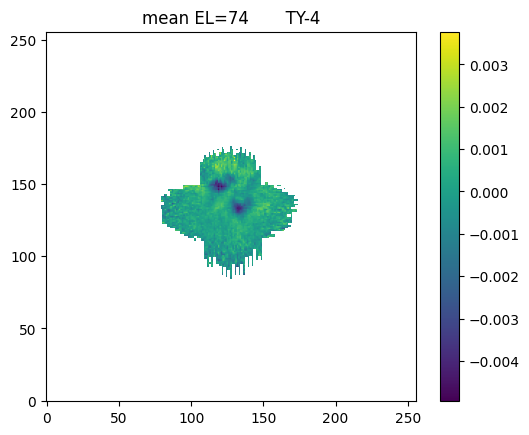

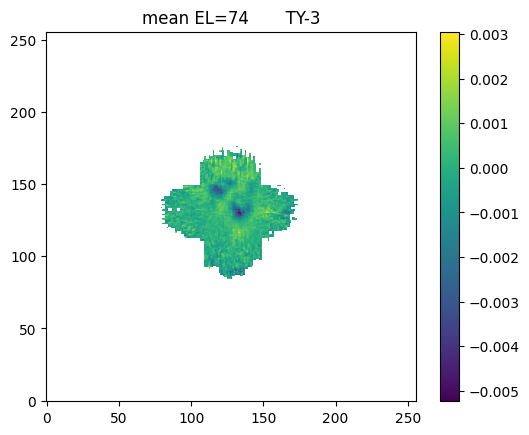

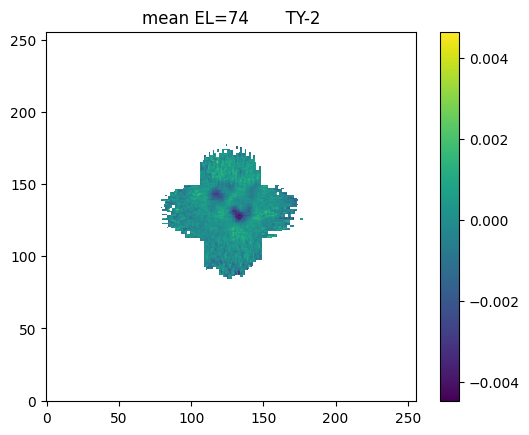

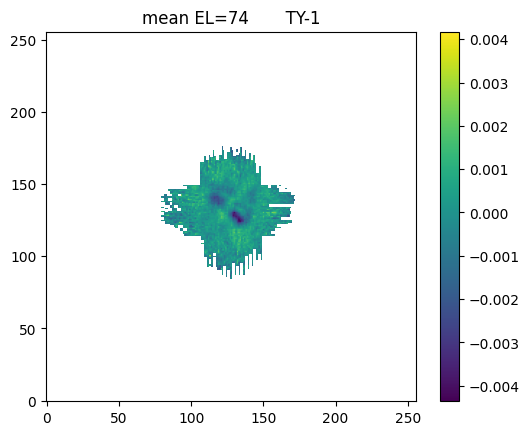

In [6]:
step = 0
mappe_filt_focus = []
mappe_unfilt_focus = []
mappe_counts_focus = []
mappe_std_focus = []

from photutils.aperture import CircularAperture

r_beam = 6/cfg['pixel_size'] #risoluzione mistral
#r_beam = 30/cfg['pixel_size'] #regione di r 1 arcmin (come NIKA2)
beam = CircularAperture((50,50), r_beam)

mean_EL = np.rad2deg(np.nanmean(coords['el_discos']))
mean_AZ = np.rad2deg(np.nanmean(coords['az_discos']))

print(name_schedule)

for y in range_pos:
    stacked_filt = np.nanmean(np.dstack(mappe_filt[0+step:n_ch+step]),2)
    stacked_unfilt = np.nanmean(np.dstack(mappe_unfilt[0+step:n_ch+step]),2)
    stacked_counts = np.nansum(np.dstack(counts[0+step:n_ch+step]),2)
    stacked_std = np.nanstd(np.dstack(mappe_filt[0+step:n_ch+step]),2)
    if cfg['plot_maps']['plot_filt']==True: 
        fig = plt.figure()
        #plt.subplot(projection=scan_wcs)
        plt.imshow(stacked_filt, origin='lower')
        #beam.plot()
        #plt.axhline(64)
        #plt.axvline(64)
        plt.colorbar()
        plt.title(f'mean EL={mean_EL:.0f}       '+'TY'+ str(y))
    if cfg['plot_maps']['plot_unfilt']==True:    
        plt.show()
        plt.imshow(stacked_unfilt,origin='lower')
        #plt.axhline(64)
        #plt.axvline(64)
        plt.colorbar()
        plt.title('TY'+ str(y))
        plt.show()
    if cfg['plot_maps']['plot_counts']==True:    
        plt.imshow(stacked_counts,origin='lower')
        #plt.axhline(64)
        #plt.axvline(64)
        plt.colorbar()
        plt.title('TY'+ str(y))
        plt.show()
    if cfg['plot_maps']['plot_std']==True:
        fig = plt.figure()
        plt.subplot(projection=scan_wcs)
        plt.imshow(stacked_std,origin='lower')
        plt.colorbar()
        plt.show()
        
    mappe_filt_focus.append(stacked_filt)
    mappe_unfilt_focus.append(stacked_unfilt)
    mappe_counts_focus.append(stacked_counts)
    mappe_std_focus.append(stacked_std)
    step += n_ch
    


In [7]:
#SAVING MAP as file fits
if cfg['path_saved_maps'] == 0:
    path_map = cfg['paths']['tods'] + '_maps/'
elif type(cfg['path_saved_maps']) == str:
    path_map = cfg['path_saved_maps']

if os.path.isdir(path_map)==False:
    os.mkdir(path_map)
print('Map save in folder:', path_map)

date_hour = path_map.split('MISTRAL')[0].split('/')[-1]
date_obs = date_hour.split('-')[0]

if cfg['save_maps']==True:
    n=0
    step=0
    for y in range_pos:
        fits_name = date_hour + name_target + '_TZ' + str(cfg['paths']['tods'].split('TZ')[-1]) + '_TY' + str(y) + '_map'
        myfile = path_map + fits_name + '.fits'
        if os.path.isfile(myfile):
            os.remove(myfile)
        hdu_list = []
        cards_list = []
        cards_list.append(fits.Card('TARGET', name_target))
        cards_list.append(fits.Card('HIERARCH Date', date_obs))
        cards_list.append(fits.Card('HIERARCH Mean Elevation', mean_EL, 'deg'))
        cards_list.append(fits.Card('HIERARCH Mean Azimuth', mean_AZ, 'deg'))
        cards_list.append(fits.Card('HIERARCH Schedule Name', subscan.name_schedule))
        cards_list.append(fits.Card('HIERARCH TY', str(y)))
        cards_list.append(fits.Card('HIERARCH RA center scan', subscan.ra_center, 'Source RA at J2000 (radians)'))
        cards_list.append(fits.Card('HIERARCH dec center scan', subscan.dec_center, 'Source dec at J2000 (radians'))
        cards_list.append(fits.Card('HIERARCH Pixel size (arcsec)', cfg['pixel_size'], 'arcsec'))
        cards_list.append(fits.Card('HIERARCH Projection', cfg['binner']['projection']+'--'+cfg['binner']['frame']))
        cards_list.append(fits.Card('HIERARCH Num chp map', cfg['num_ch_map']))
        cards_list.append(fits.Card('HIERARCH Path TODs', cfg['paths']['tods'].split('/')[-1]))
        if type(cfg['paths']['resp'])==str:
            cards_list.append(fits.Card('HIERARCH File chp responsivity', cfg['paths']['resp'].split('/')[-1]))
        else:
            cards_list.append(fits.Card('HIERARCH File chp responsivity', 'Not used'))
        cards_list.append(fits.Card('HIERARCH File offset pixel', cfg['paths']['offset_pixel'].split('/')[-1]))
        if cfg['paths']['skydip'] == False:
            cards_list.append(fits.Card('HIERARCH Skydip calibration', 'No'))
        elif type(cfg['paths']['skydip']) == str:
            cards_list.append(fits.Card('HIERARCH Skydip calibration', 'Yes'))
            cards_list.append(fits.Card('HIERARCH Path skydip', cfg['paths']['skydip'].split('/')[-1]))
            cards_list.append(fits.Card('HIERARCH tau', cfg['paths']['tau']))
            cards_list.append(fits.Card('HIERARCH T atm', cfg['paths']['T_atm']))
        cards_list.append(fits.Card('HIERARCH Filtering with gen CM', cfg['filtering']['gen_cm']))
        cards_list.append(fits.Card('HIERARCH Filtering with cust CM', cfg['filtering']['cust_cm']))
        cards_list.append(fits.Card('HIERARCH Unfilt map saved', cfg['unfilt_map']))
        #cards_list.append(fits.Card('HIERARCH ', cfg['']))
        hdr = fits.Header(cards=cards_list)
        prim_hdu0 = fits.PrimaryHDU(header=hdr)
        header_wcs = scan_wcs.to_header()
        prim_hdu1 = fits.ImageHDU(header=header_wcs, data=mappe_filt_focus[n], name='FILT MAP')
        prim_hdu2 = fits.ImageHDU(header=header_wcs, data=mappe_counts_focus[n], name='COUNTS MAP')
        prim_hdu3 = fits.ImageHDU(header=header_wcs, data=mappe_unfilt_focus[n], name='UNFILT MAP')
        prim_hdu4 = fits.ImageHDU(header=header_wcs, data=mappe_std_focus[n], name='STD MAP')
        fits_hdu_list = fits.HDUList([prim_hdu0, prim_hdu1, prim_hdu2, prim_hdu3, prim_hdu4])

        fits_hdu_list.writeto(myfile, overwrite=True)

        if cfg['save_single_pixel_maps']==True: 
        #SAVING single pixel maps as a fits file
            path_single_map = path_map + name_target + '_TY' + str(y) + '_single_pixel_maps/'
            if os.path.isdir(path_single_map)==False:
                os.mkdir(path_single_map)
            print('Single pixel maps save in folder:', path_single_map)

            for i in range(subscan.num_feed):#len(maps_all)
                fits_name = name_target + '_chp_'+ str(i).zfill(3)
                myfile = path_single_map + fits_name + '.fits'
                if os.path.isfile(myfile):
                    os.remove(myfile)
                hdu_list = []
                cards_list = []
                cards_list.append(fits.Card('HIERARCH Channel name', 'chp_'+ str(i).zfill(3)))
                cards_list.append(fits.Card('TARGET', name_target))
                cards_list.append(fits.Card('HIERARCH Date', date_obs))
                cards_list.append(fits.Card('HIERARCH Mean Elevation', mean_EL, 'deg'))
                cards_list.append(fits.Card('HIERARCH Schedule Name', subscan.name_schedule))
                cards_list.append(fits.Card('HIERARCH TY', str(y)))
                cards_list.append(fits.Card('HIERARCH RA center scan', subscan.ra_center, 'Source RA at J2000 (radians)'))
                cards_list.append(fits.Card('HIERARCH dec center scan', subscan.dec_center, 'Source dec at J2000 (radians'))
                cards_list.append(fits.Card('HIERARCH Pixel size (arcsec)', cfg['pixel_size'], 'arcsec'))
                cards_list.append(fits.Card('HIERARCH Projection', cfg['binner']['projection']+'--'+cfg['binner']['frame']))
                cards_list.append(fits.Card('HIERARCH Num chp map', cfg['num_ch_map']))
                cards_list.append(fits.Card('HIERARCH Path TODs', cfg['paths']['tods'].split('/')[-1]))
                if type(cfg['paths']['resp'])==str:
                    cards_list.append(fits.Card('HIERARCH File chp responsivity', cfg['paths']['resp'].split('/')[-1]))
                else:
                    cards_list.append(fits.Card('HIERARCH File chp responsivity', 'Not used'))
                cards_list.append(fits.Card('HIERARCH File offset pixel', cfg['paths']['offset_pixel'].split('/')[-1]))
                if cfg['paths']['skydip'] == False:
                    cards_list.append(fits.Card('HIERARCH Skydip calibration', 'No'))
                elif type(cfg['paths']['skydip']) == str:
                    cards_list.append(fits.Card('HIERARCH Skydip calibration', 'Yes'))
                    cards_list.append(fits.Card('HIERARCH Path skydip', cfg['paths']['skydip'].split('/')[-1]))
                    cards_list.append(fits.Card('HIERARCH tau', cfg['paths']['tau']))
                    cards_list.append(fits.Card('HIERARCH T atm', cfg['paths']['T_atm']))
                cards_list.append(fits.Card('HIERARCH Filtering with gen CM', cfg['filtering']['gen_cm']))
                cards_list.append(fits.Card('HIERARCH Filtering with cust CM', cfg['filtering']['cust_cm']))
                cards_list.append(fits.Card('HIERARCH Unfilt map saved', cfg['unfilt_map']))

                hdr = fits.Header(cards=cards_list)
                prim_hdu0 = fits.PrimaryHDU(header=hdr)
                header_wcs = scan_wcs.to_header()
                prim_hdu1 = fits.ImageHDU(header=header_wcs, data=mappe_filt[0+step:subscan.num_feed+step], name='FILT MAP')
                prim_hdu2 = fits.ImageHDU(header=header_wcs, data=counts[0+step:subscan.num_feed+step], name='COUNTS MAP')
                prim_hdu3 = fits.ImageHDU(header=header_wcs, data=mappe_unfilt[0+step:subscan.num_feed+step], name='UNFILT MAP')
                fits_hdu_list = fits.HDUList([prim_hdu0, prim_hdu1, prim_hdu2, prim_hdu3])

                fits_hdu_list.writeto(myfile, overwrite=True)
                
        step += subscan.num_feed    
        n +=1


Map save in folder: /Users/eleonora/Desktop/SRT-marzo/20250404-181903-MISTRAL-YOFFSET_MARS_TZ-2_maps/


663.5742187499998 57.09609375


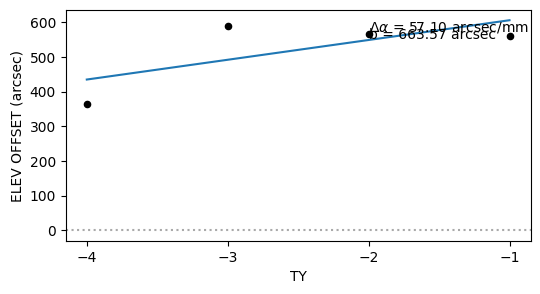

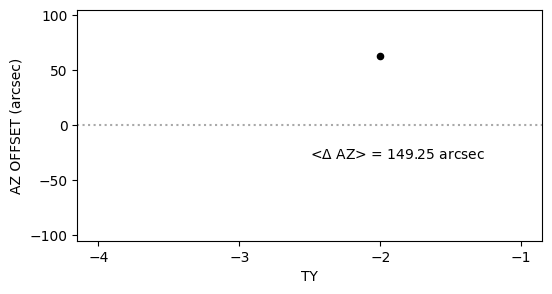

In [8]:
#CALCOLO  SPOSTAMENTO Dalpha PER YOFFSET

el_of_min = []
az_of_min = []

el_cen = scan_wcs.pixel_to_world(64, 64)[1].value
az_cen = scan_wcs.pixel_to_world(64, 64)[0].value

for map in mappe_filt_focus:
    el_of_min.append(((scan_wcs.pixel_to_world(np.nanargmin(map)/128, np.nanargmin(map)/128)[1].value - el_cen)*60 )*60)
    az_of_min.append(((scan_wcs.pixel_to_world(np.nanargmin(map)%128, np.nanargmin(map)%128)[0].value - az_cen)*60 )*60)

ty = list(np.copy(range_pos))

import numpy.polynomial.polynomial as poly
'''
ty = ty[3:6] + ty[7:] #ty[3:4]+ty[5:-3]+ty[-2:-1]
el_of_min = el_of_min[3:6] + el_of_min[7:] #el_of_min[3:4]+el_of_min[5:-3]+el_of_min[-2:-1]
az_of_min = az_of_min[3:6] + az_of_min[7:] #az_of_min[3:4]+az_of_min[5:-3]+az_of_min[-2:-1]
'''
linear = poly.Polynomial.fit(ty, el_of_min, 1)
b, m = linear.convert().coef
print(b, m)

plt.figure(figsize=(6,3))
plt.axhline(0, linestyle='dotted', c='darkgrey')
plt.plot(ty, m*np.array(ty) + b)
plt.scatter(ty, el_of_min, s=20, c='black')
#plt.ylim(-105, 105)
plt.ylabel('ELEV OFFSET (arcsec)')
plt.xlabel('TY')
plt.xticks(ty)
plt.text(ty[-2], m*np.array(ty[2]) + b + 25, r'$\Delta \alpha$ = ' + f'{m:.2f} arcsec/mm')
plt.text(ty[-2], m*np.array(ty[2]) + b +3, r'b = ' + f'{b:.2f} arcsec')
plt.show()

plt.figure(figsize=(6,3))
plt.axhline(0, linestyle='dotted', c='darkgrey')
plt.scatter(ty, az_of_min, s=20, c='black')
plt.axhline(np.nanmean(az_of_min))
plt.text((ty[-1]+ty[0])/2, -30, r'<$\Delta$ AZ> = ' + f'{np.nanmean(az_of_min):.2f} arcsec')
plt.ylim(-105, 105)
plt.ylabel('AZ OFFSET (arcsec)')
plt.xlabel('TY')
plt.xticks(ty)
plt.show()


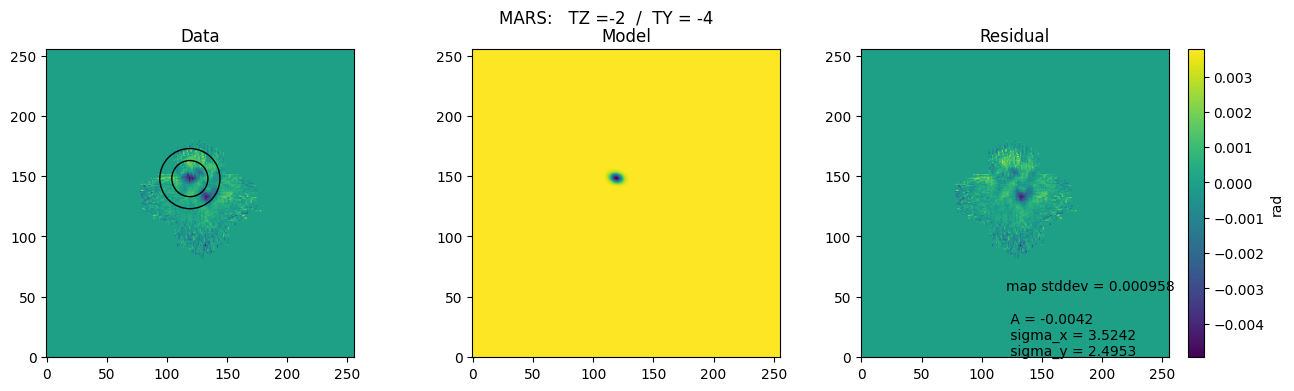

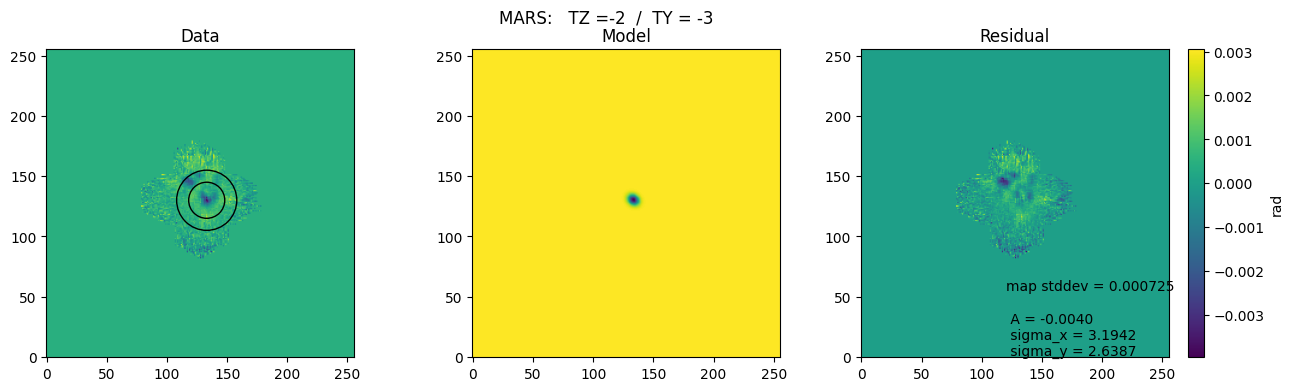

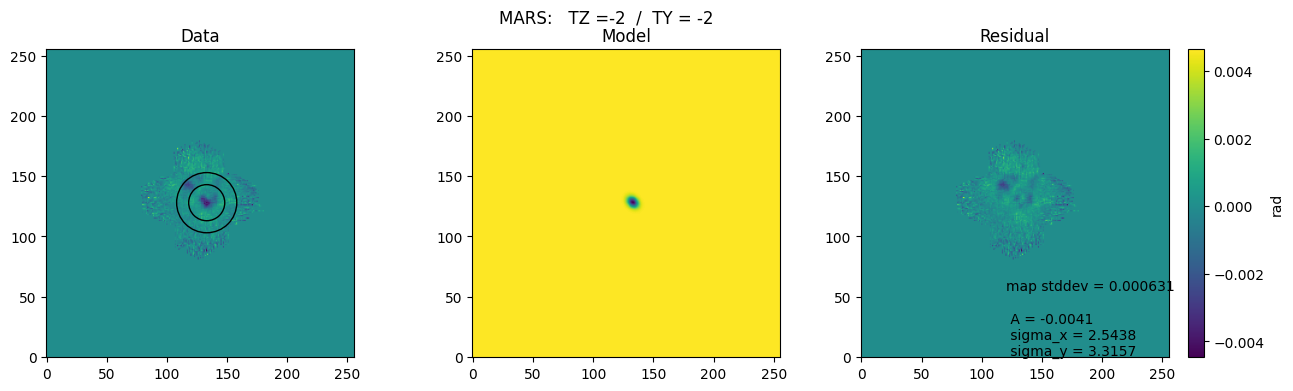

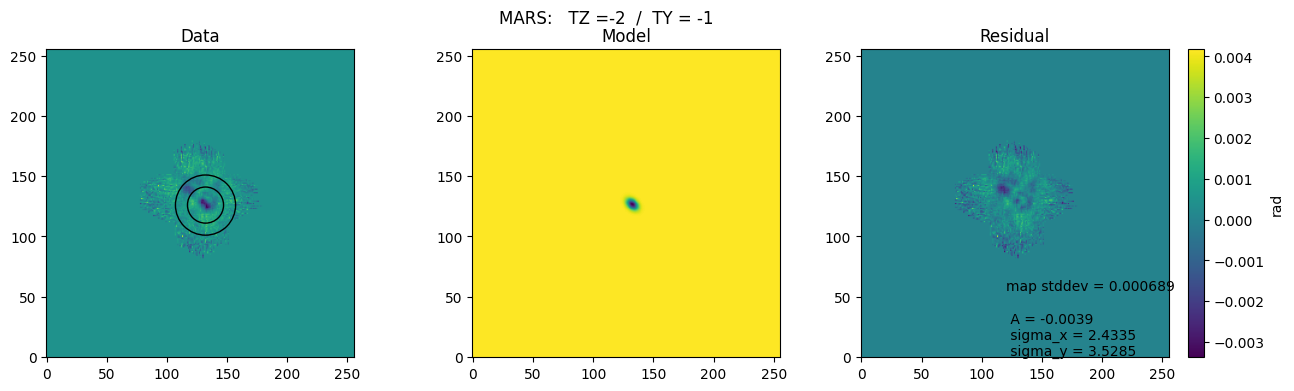

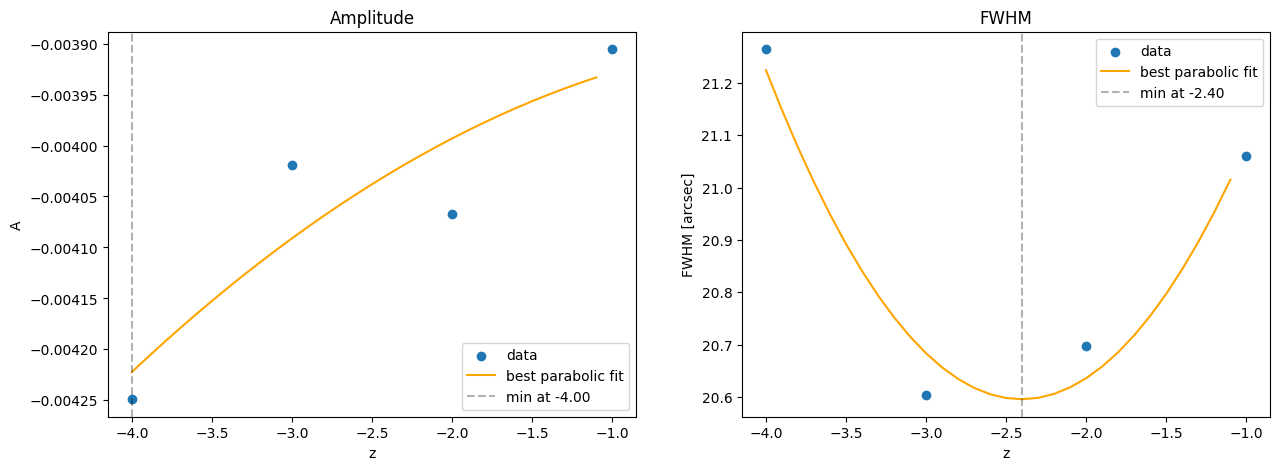

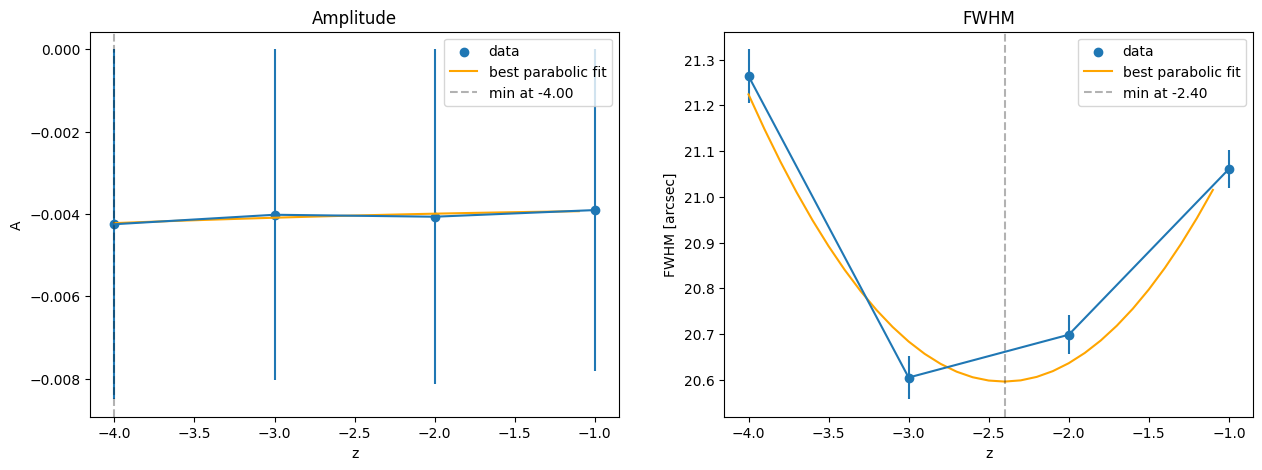

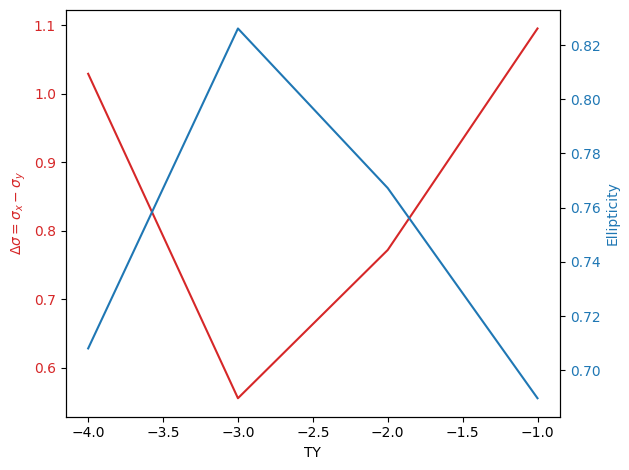

In [9]:
import scipy.ndimage as ndimage
from astropy.convolution import convolve_fft

map_model = []
srp_tz = [] #spostamento focus asse z
srp_ty = [] #spostamento focus asse y
srp_tx = [] #spostamento focus asse x
el_focus = [] #el a cui è stato fatto il focus scan
fwhm_focus = []
x0_focus = []
y0_focus = []
A_focus = []
sigma1_focus = []
sigma2_focus = []
A_err_focus = []
sigma1_err_focus = []
sigma2_err_focus = []
chi2 = []
rms =[]
AIC = []
res_map = []

A_mappa = []

for i in range(len(mappe_filt_focus)):
    
    cut_map = mappe_filt_focus[i]
    '''
    if i==1:
        cut_map = mappe_filt_focus[i][80:120, 40:80]
    if i==2:
        cut_map = mappe_filt_focus[i][60:100, 40:80]
    if i==3:
        cut_map = mappe_filt_focus[i][50:100, 30:80]
    if i==4:
        cut_map = mappe_filt_focus[i][50:100, 40:90]
    '''
    cut_map[np.isnan(cut_map)]=0
    #num_pixel = (100-20)**2
    #x, y = np.meshgrid(np.arange(0,np.shape(m)[0]), np.arange(0,np.shape(m)[1]))
    #x0 = x.ravel()[peak] #x position of the brightest pixel
    #y0 = y.ravel()[peak]
    #cut_map = m[y0-15:y0+15, x0-15:x0+15].T
    #cut_map[np.isnan(cut_map)]=0

    x, y = np.meshgrid(np.arange(0,np.shape(cut_map)[1]), np.arange(0,np.shape(cut_map)[0]))
    img_smooth = ndimage.gaussian_filter(cut_map, sigma=(2, 2), order=0)
    peak = np.nanargmin(img_smooth)
    #peak = np.nanargmax(img_smooth)
    x0 = x.ravel()[peak] #x position of the brightest pixel
    y0 = y.ravel()[peak]
    '''
    if i==4:
        x0=64
        y0=55
        
    if i==5:
        x0=64
        y0=45
        
    if i==6:
        x0=64
        y0=35
    '''
    '''
    cut_map = cut_map[y0-5:y0+5, x0-5:x0+5]
    num_pixel = 10**2 #(80-45)**2
    x, y = np.meshgrid(np.arange(0,np.shape(cut_map)[1]), np.arange(0,np.shape(cut_map)[0]))
    peak = np.nanargmax(cut_map)
    x0 = x.ravel()[peak] #x position of the brightest pixel
    y0 = y.ravel()[peak]
    '''
    positions = (x0, y0)
    r_min = 15
    r_max = 25
    annulus_aperture = CircularAnnulus(positions, r_in=r_min, r_out=r_max)
    aperstats = ApertureStats(cut_map, annulus_aperture) #ApertureStats(cut_map**2, annulus_aperture)
    stddev_data = aperstats.std #np.sqrt(aperstats.mean)
    
    # Fit the data using astropy.modeling
    #p_init = functional_models.Gaussian2D(amplitude=np.max(cut_map), x_mean=x0, y_mean=y0)
    #model = functional_models.Gaussian2D(amplitude=np.max(cut_map), x_mean=x0, y_mean=y0, x_stddev=1.5, y_stddev=1.5) + functional_models.Gaussian2D(amplitude=np.max(cut_map), x_mean=x0, y_mean=y0, x_stddev=7, y_stddev=7)
    pars = Parameters()
    delta = 5 # prior width on beam position for the fit
    A = np.nanmin(cut_map)
    #A = np.nanmax(cut_map)
    
    pars.add("A", value=A, min=0, max=A*1.5)
    pars.add("x0", value=x0, min=x0-delta, max=x0+delta)
    pars.add("y0", value=y0, min=y0-delta, max=y0+delta)
    #pars.add("sigma", value=1, min=0.5, max=6)
    pars.add("sigma_x", value=1, min=0.5, max=5)
    pars.add("sigma_y", value=1, min=0.5, max=5)
    pars.add("theta", value=0, min=-180, max=+180)
    
    cov_matrix = np.diag(np.full(n_pixel, stddev_data**2/n_pixel))

    
    #model = Model(gauss2D_circ, independent_vars=('x','y'), nan_policy="omit")
    model = Model(focus_lib.gauss2D_rot, independent_vars=('x','y'), nan_policy="omit")

    #fitter = fitting.LevMarLSQFitter(calc_uncertainties=True)
    #result = fitter(model, x, y, cut_map, )
    
    fit = model.fit(cut_map, x=x, y=y, params=pars, method="leastsq", scale_covar=True, calc_covar=True)
    result = model.func(x, y, **fit.best_values)
    map_model.append(result)
    #print(fit.fit_report())
    '''
    
    model = models.AiryDisk2D(amplitude=A, x_0=x0, y_0=y0, radius=delta)
    fittare = fitting.LevMarLSQFitter()
    fit = fittare(model, x, y, cut_map)
    result = fit(x,y)
    '''
    #tz = tods_files[i].split('.fits')[0].split('TY')[-1].split('_')[0]
    #ty = myfiles[i].split('.fits')[0].split('TY')[-1].split('_')[0]
    tz = tods_files[i].split('TZ')[1].split('/')[0]
    ty = range_pos
    
    srp_tz.append(float(tz)) #spostamento focus asse z
    srp_ty.append(float(ty[i])) #spostamento focus asse y
    el_focus.append(0)#float(np.mean(np.hstack(all_el)).ravel()))
    fwhm_focus.append(0)
    x0_focus.append(fit.params['x0'].value)
    y0_focus.append(fit.params['y0'].value)
    A_mappa.append(np.nanmin(cut_map))
    A_focus.append(fit.params['A'].value)
    A_err_focus.append(fit.params['A'].stderr)
    #sigma1_focus.append(fit.params['sigma'].value)
    #sigma1_err_focus.append(fit.params['sigma'].stderr)
    sigma1_focus.append(fit.params['sigma_x'].value) #(fit.params['sigma_x'].value)
    sigma1_err_focus.append(fit.params['sigma_x'].stderr) #(fit.params['sigma_x'].stderr)
    sigma2_focus.append(fit.params['sigma_y'].value)
    sigma2_err_focus.append(fit.params['sigma_y'].stderr)
    chi2.append(fit.chisqr)
    rms.append(np.sqrt(np.mean(np.square(cut_map - result))))
    AIC.append(fit.aic)
    '''
    srp_tz.append(float(tz)) #spostamento focus asse z
    srp_ty.append(float(ty)) #spostamento focus asse y
    el_focus.append(0)#float(np.mean(np.hstack(all_el)).ravel()))
    fwhm_focus.append(0) 
    A_focus.append(fit.amplitude.value)
    #sigma1_focus.append(fit.params['sigma'].value)
    #sigma1_err_focus.append(fit.params['sigma'].stderr)
    sigma1_focus.append(fit.radius.value) #(fit.params['sigma_x'].value)
    sigma2_focus.append(0) #fit.params['sigma_y'].value)
    sigma2_err_focus.append(0) #fit.params['sigma_y'].stderr)
    chi2.append(0)#fit.chisqr)
    rms.append(np.sqrt(np.mean(np.square(cut_map - result))))
    AIC.append(0)#fit.aic)
    '''
    
    res_map.append(cut_map - result)
    
    # Plot the data with the best-fit model
    fig = plt.figure(figsize=(16, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(cut_map, origin='lower')#, interpolation='nearest', vmin=-1e4, vmax=5e4)
    annulus_aperture.plot()
    plt.title("Data")
    plt.subplot(1, 3, 2)
    plt.imshow(result, origin='lower')#, interpolation='nearest', vmin=-1e4,vmax=5e4)
    plt.title("Model")
    plt.subplot(1, 3, 3)
    plt.imshow(cut_map - result, origin='lower')#, interpolation='nearest', vmin=-1e4,vmax=5e4)
    #plt.text(120, 1, f'map stddev = {stddev_data:.6f} \n \n A = {fit.params['A'].value:.4f} \n sigma = {fit.params['sigma'].value:.4f} ')
    plt.text(120, 1, f'map stddev = {stddev_data:.6f} \n \n A = {fit.params['A'].value:.4f} \n sigma_x = {fit.params['sigma_x'].value:.4f} \n sigma_y = {fit.params['sigma_y'].value:.4f}')
    plt.colorbar(label="rad", pad=0.05)
    plt.title("Residual")
    fig.subplots_adjust(wspace=0.1)
    fig.suptitle(name_target + ':   TZ ='+ tz + '  /  TY = ' + str(ty[i]))
    plt.show()
    #plt.savefig('/Users/eleonora/Desktop/mistral/FOCUS/FIT_'+namefolder[i]+'-'+namefile[i]+'.png')
    

for i in range(len(A_err_focus)):
    if A_err_focus[i]==None or A_err_focus[i]>A_focus[i]:
        A_err_focus[i]=A_focus[i]
for i in range(len(sigma1_err_focus)):
    if sigma1_err_focus[i]==None or sigma1_err_focus[i]>sigma1_focus[i]:
        sigma1_err_focus[i]=sigma1_focus[i]
'''
for i in range(len(sigma1_err_focus)):
    if sigma2_err_focus[i]==None or sigma2_err_focus[i]>sigma2_focus[i]:
        sigma2_err_focus[i]=sigma2_focus[i]
'''
min = 0
max = len(srp_ty)
plot_tz = srp_tz[min:max]
plot_ty = srp_ty[min:max]
plot_A = A_focus[min:max]
plot_Aerr = A_err_focus[min:max]
plot_sigma = np.nanmean((sigma1_focus, sigma2_focus), axis=0)[min:max]
plot_sigmaerr = sigma1_err_focus[min:max]

focus_lib.plot_zfocus_circ(plot_ty, plot_A, plot_Aerr, plot_sigma, plot_sigmaerr)
#focus_lib.plot_zfocus_ell(srp_tz, A_focus, np.abs(A_err_focus), sigma1_focus, sigma1_err_focus, sigma2_focus, sigma2_err_focus, A_mappa)
#focus_lib.plot_yfocus(srp_ty, A_focus, A_err_focus, sigma1_focus, sigma1_err_focus)

'''
fig, ax = plt.subplots(1, 2, figsize=(15,5))
ax[0].plot(srp_tz, A_focus, label='data')
ax[0].errorbar(srp_tz, A_focus, A_err_focus)
result_gauss = gauss_model.fit(A_focus[0:-1], x=srp_tz[0:-1], amp=np.max(A_focus[0:-1]), cen=-7, wid=0.5, weights=1./np.array(A_err_focus[0:-1]))
ax[0].plot(srp_tz[0:-1], result_gauss.best_fit, '-', label='best Gaussian fit')
#plt.plot(srp_tz, result_par.best_fit, '-', label='best parabolic fit')
#ax[0].scatter(srp_tz, A_focus_conv, label='Fit on convolved image')
ax[0].set_title('Amplitude')
ax[0].set_xlabel('z')
ax[0].set_ylabel('A')
ax[1].plot(srp_tz, fwhm(sigma1_focus), label='Fit on raw image')
ax[1].errorbar(srp_tz, fwhm(sigma1_focus), sigma1_err_focus)
result_gauss1 = gauss_sigma_model.fit(sigma1_focus[0:-1], x=srp_tz[0:-1], amp=np.min(sigma1_focus[0:-1]), cen=-7, wid=0.5, weights=1./np.array(sigma1_err_focus[0:-1]))
ax[1].plot(srp_tz[0:-1], fwhm(result_gauss1.best_fit), '-', label='best Gaussian fit')
#ax[1].scatter(srp_tz, sigma_x_focus_conv, label='Fit on convolved image')
ax[1].set_title('FWHM_int')
ax[1].set_xlabel('z')
ax[1].set_ylabel('FWHM_int')
plt.show()
#plt.savefig('A_sigmaxy_focus_TZ_curve.png')
'''

#focus_lib.plot_yfocus_with_error(srp_ty, A_focus, A_err_focus, sigma1_focus, sigma1_err_focus)
focus_lib.plot_zfocus_with_error_circ(plot_ty, plot_A, np.abs(plot_Aerr), plot_sigma, plot_sigmaerr)
#focus_lib.plot_zfocus_with_error_ell(srp_tz, A_focus, np.abs(A_err_focus), sigma1_focus, sigma1_err_focus, sigma2_focus, sigma2_err_focus)

'''
ax[2].scatter(srp_ty, fwhm_arcsec(sigma2_focus), label='data')
ax[2].errorbar(srp_ty, fwhm_arcsec(sigma2_focus), sigma2_err_focus)
#result_gauss1 = par_sigma_model.fit(sigma1_focus[0:-1], x=srp_tz[0:-1])#, a=np.min(sigma1_focus[0:-1]))#, cen=-7, wid=0.5, weights=1./np.array(sigma1_err_focus[0:-1]))
fit_params_sigma2, pcov_sigma2 = scipy.optimize.curve_fit(parabola, srp_ty, sigma2_focus, sigma=sigma2_err_focus)
y_fit_sigma2 = parabola(np.arange(np.min(srp_ty), np.max(srp_ty), 0.1), *fit_params_sigma2)
ax[2].plot(np.arange(np.min(srp_ty), np.max(srp_ty), 0.1), fwhm_arcsec(y_fit_sigma2), '-', label='best parabolic fit', c='orange')
min_sigma = np.nanargmin(y_fit_sigma2)
ax[2].axvline(np.arange(np.min(srp_ty), np.max(srp_ty), 0.1)[min_sigma], label=f'min at {np.arange(np.min(srp_ty), np.max(srp_ty), 0.1)[min_sigma]:.2f}',linestyle='--',  c='black', alpha=0.3)
#ax[1].scatter(srp_tz, sigma_x_focus_conv, label='Fit on convolved image')
ax[2].legend()
ax[2].set_title('FWHM_y')
ax[2].set_xlabel('y')
ax[2].set_ylabel('FWHM [arcsec]')
fig.suptitle(f'Mean elevation =  {np.mean(elevation):.2f}')
plt.show()
'''

sigma1_focus = np.array(sigma1_focus)
sigma2_focus = np.array(sigma2_focus)

semi_major = np.max([sigma1_focus, sigma2_focus], axis=0)
semi_minor = np.min([sigma1_focus, sigma2_focus], axis=0)

delta_sigma = np.abs(sigma1_focus - sigma2_focus)
ell = semi_minor/semi_major
#ell = sigma1_focus/sigma2_focus

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('TY')
ax1.set_ylabel(r'$\Delta\sigma = \sigma_x - \sigma_y $', color=color)
ax1.plot(srp_ty, delta_sigma, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Ellipticity', color=color)  # we already handled the x-label with ax1
ax2.plot(srp_ty, ell, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()





In [10]:
np.sqrt(13.5**2+11.5**2) #convoluzione beam di mistral e estensione di marte 

17.7341478509682

[119.11147676057509, 133.2956657878774, 132.7699359718597, 132.3639051930055]
[148.31351357832312, 130.1772940364117, 128.22843147732607, 126.4115350206442]
132.97577321968012 176.25775247055904


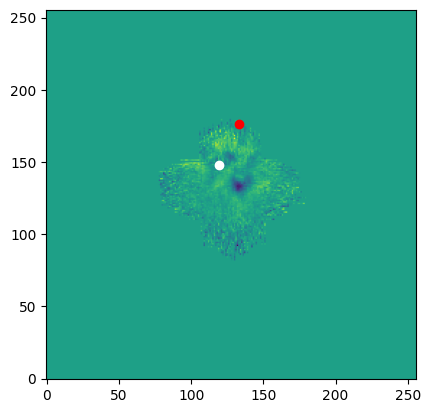

120.28374999914458 202.7946891148458


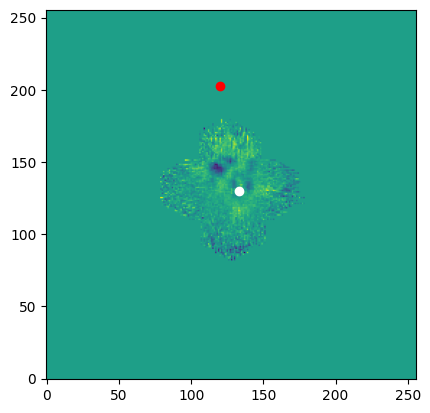

122.93587892431178 172.56503890138137


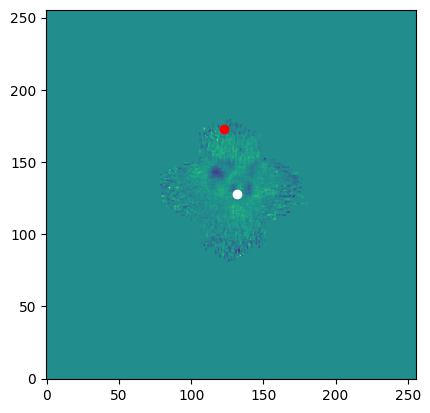

129.66873430203142 142.98213318955982


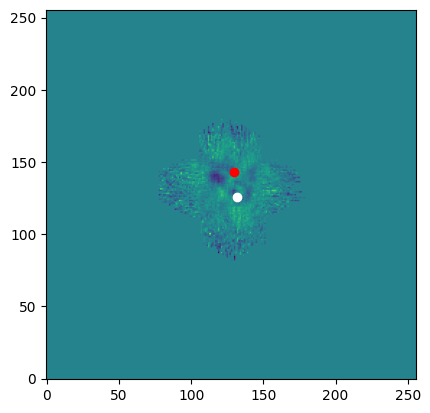

(-5.0, 100.0)

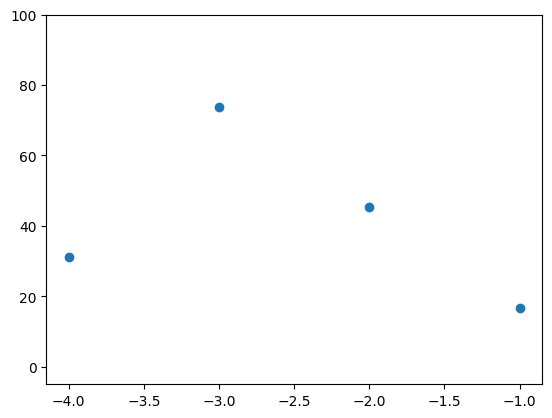

In [11]:
import photutils

centroid_x = []
centroid_y = []
print(x0_focus)
print(y0_focus)

int_y = [[88,128], [70,110], [60, 100], [50,90], [40,80]]
for i in range(len(res_map)):
    img_res = res_map[i]#[40:80, int_y[i][0]:int_y[i][1]]
    x, y = photutils.centroids.centroid_com(img_res)
    print(x, y)
    plt.imshow(res_map[i], origin='lower')
    plt.scatter(x,y, color='red')
    plt.scatter(int(x0_focus[i]), int(y0_focus[i]), color='w')
    #plt.scatter(int(x0_focus[i])-20, int(y0_focus[i])-20, color='w')
    #plt.scatter(int(x0_focus[i])+20, int(y0_focus[i])+20, color='w')
    plt.show()
    centroid_x.append(x)
    centroid_y.append(y)

x0_focus = np.array(x0_focus)
y0_focus = np.array(y0_focus)
centroid_x = np.array(centroid_x)
centroid_y = np.array(centroid_y)

delta_cen = np.sqrt((x0_focus - centroid_x)**2 + (y0_focus-centroid_y)**2)
plt.scatter(srp_ty, delta_cen)
plt.ylim(-5,100)

In [12]:
subscan_table

TY,n_subscan,ch,t,lon,lat,tod_raw,tod_dt,ch_masks,tod_filt,cust_cm
bytes5,bytes3,int32,float64,float64,float64,float64,float64,bool,float64,float64
-1,024,0,60769.76669747635,-0.00013361624667795137,-0.0004525092414117912,-0.2686505121031056,0.0020370768066781397,True,0.0019442177707186237,9.285903595951606e-05
-1,024,0,60769.76669752376,-0.0001336413879739643,-0.00045177870169748203,-0.26905365922257707,0.0016389229628382962,True,0.0008619421512052097,0.0007769808116330865
-1,024,0,60769.76669757117,-0.00013366653065542754,-0.0004510481620315692,-0.2708640589944518,-0.00016648353340481536,True,-5.106041493599149e-05,-0.00011542311846882387
-1,024,0,60769.76669761857,-0.00013369167086463662,-0.0004503177345288835,-0.2693206826317043,0.0013818861049743614,True,0.0008981907999388943,0.0004836953050354671
-1,024,0,60769.76669766598,-0.0001337168163185624,-0.0004495871949598729,-0.2714112555204765,-0.0007036935081662365,True,-0.0005728353475648432,-0.00013085816060139338
-1,024,0,60769.766697713385,-0.00013374195929981574,-0.00044885676755402324,-0.2690922781744278,0.0016202771135140903,True,0.0010304933282604158,0.0005897837852536745
-1,024,0,60769.766697760795,-0.000133767107526647,-0.00044812622808195027,-0.2706954083904385,2.2140173135065666e-05,True,0.0001397864244469215,-0.00011764625131185584
-1,024,0,60769.766697808205,-0.00013379225713981463,-0.00044739568865833897,-0.27105751416064955,-0.00033497232144436007,True,-0.0010051268743491734,0.0006701545529048134
-1,024,0,60769.76669785561,-0.00013381740427878745,-0.0004466652613978727,-0.2724530342365832,-0.0017254991217463544,True,-0.0014771305846687489,-0.00024836853707760565


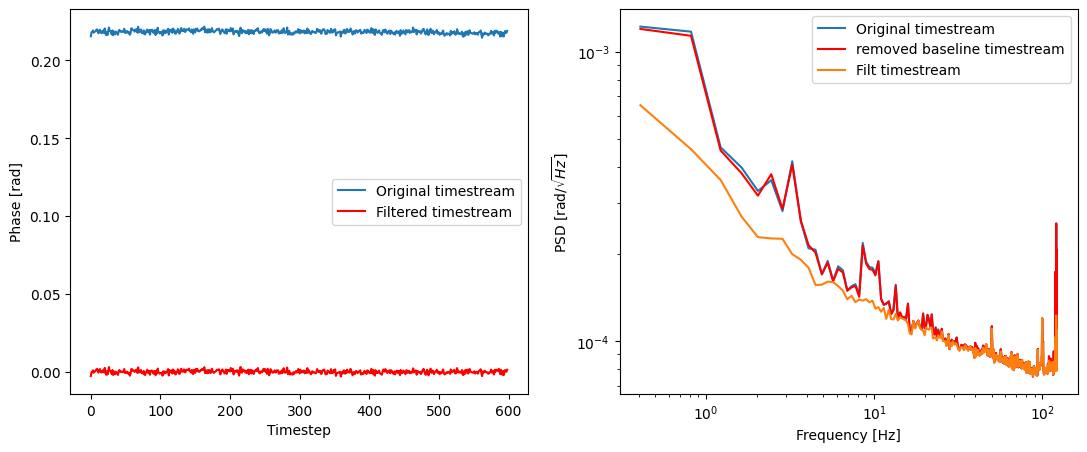

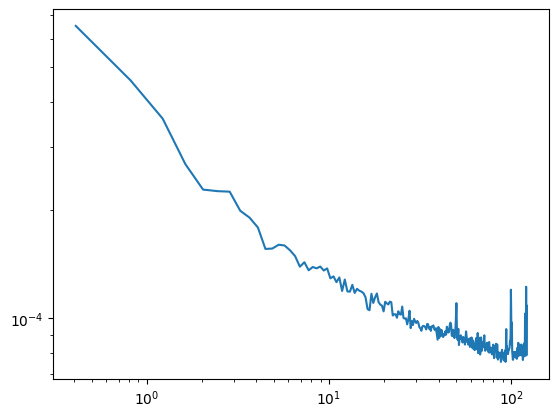

In [13]:
spec_raw_all = []
spec_dt_all = []
spec_filt_all = []
for i in range(subscan.num_feed):
    ts_raw_000 = subscan_table['tod_raw'][subscan_table['ch']==i][700:]
    ts_dt_000 = subscan_table['tod_dt'][subscan_table['ch']==i][700:]
    ts_filtered_000 = subscan_table['tod_filt'][subscan_table['ch']==i][700:]

    f, P= scipy.signal.periodogram(ts_raw_000, fs=244.14, scaling='density')
    f1, P1= scipy.signal.periodogram(ts_dt_000, fs=244.14, scaling='density')
    f2, P2= scipy.signal.periodogram(ts_filtered_000, fs=244.14, scaling='density')
    
    spec_raw_all.append(np.sqrt(P[1:]))
    spec_dt_all.append(np.sqrt(P1[1:]))
    spec_filt_all.append(np.sqrt(P2[1:]))

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(13,5))
ax1.plot(ts_raw_000, label='Original timestream')
ax1.plot(ts_filtered_000, label = 'Filtered timestream', c='red')
ax1.set_xlabel('Timestep')
ax1.set_ylabel('Phase [rad]')
ax1.legend()

spec_raw = np.nanmean(spec_raw_all,0)
spec_dt = np.nanmean(spec_dt_all,0)
spec_filt = np.nanmean(spec_filt_all,0)

ax2.plot(f[1:], spec_raw, label='Original timestream')
ax2.plot(f[1:], spec_dt, label = 'removed baseline timestream', c='red')
ax2.plot(f[1:], spec_filt, label='Filt timestream')
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_ylabel(r'PSD [rad/$\sqrt{Hz}$]')
ax2.set_xlabel('Frequency [Hz]')
ax2.legend()
plt.show()

plt.plot(f[1:], spec_filt)
plt.xscale("log")
plt.yscale("log")
plt.show()




In [14]:
'''
from astropy.io import fits

hdul = fits.open(tods_files[0])

hdr = []
hdr_all = hdul['PH TABLE'].header
for i in range(8, len(hdr_all)-1, 2): #faccio len(header)-1 perche l'ultimo header non lo voglio. Se non metto il -1 me lo salva
    hdr.append(hdr_all[i])
'''


"\nfrom astropy.io import fits\n\nhdul = fits.open(tods_files[0])\n\nhdr = []\nhdr_all = hdul['PH TABLE'].header\nfor i in range(8, len(hdr_all)-1, 2): #faccio len(header)-1 perche l'ultimo header non lo voglio. Se non metto il -1 me lo salva\n    hdr.append(hdr_all[i])\n"